In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/adult.csv', na_values='?')

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [2]:
print(df['hours-per-week'].describe())
print(f"\nValori lipsă în target: {df['hours-per-week'].isnull().sum()}")

count    48842.000000
mean        40.422382
std         12.391444
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

Valori lipsă în target: 0


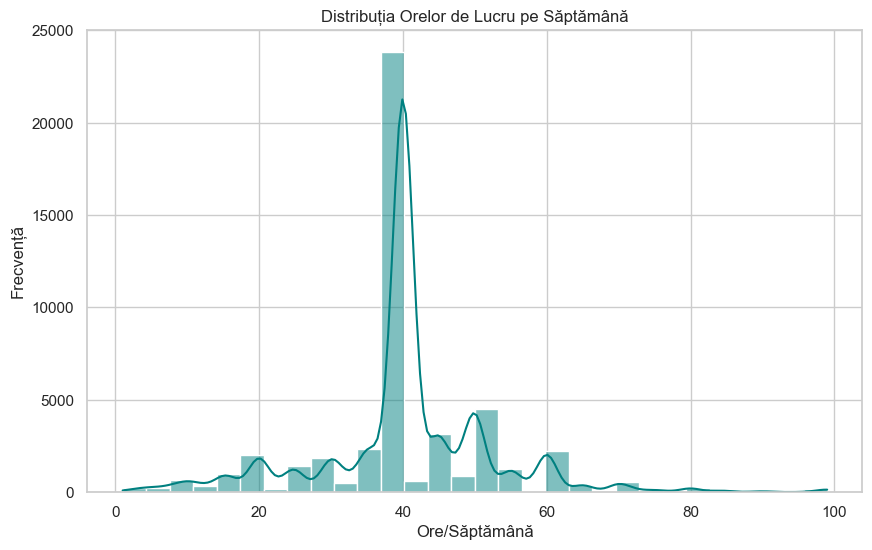

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['hours-per-week'], bins=30, kde=True, color='teal')
plt.title('Distribuția Orelor de Lucru pe Săptămână')
plt.xlabel('Ore/Săptămână')
plt.ylabel('Frecvență')
plt.show()

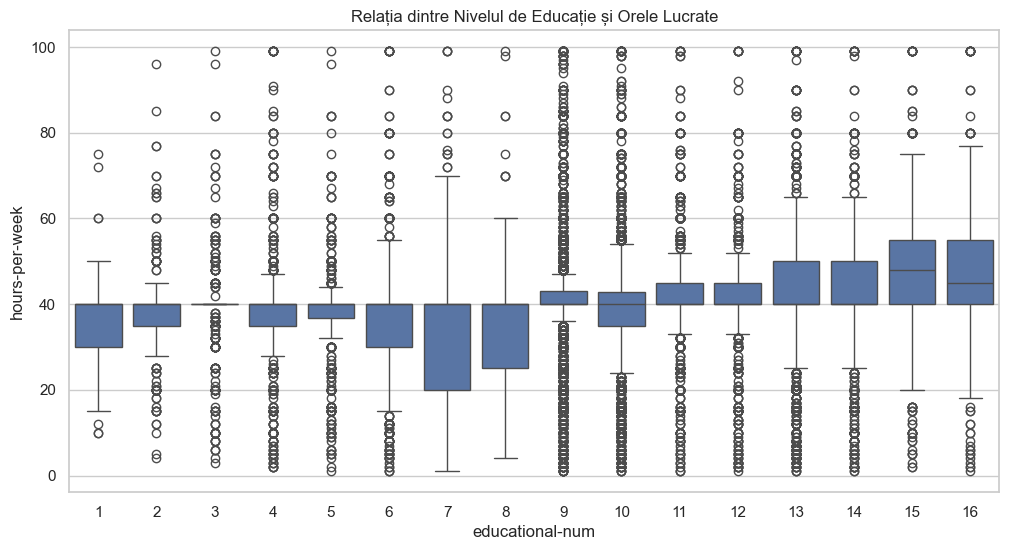

In [4]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='educational-num', y='hours-per-week', data=df)
plt.title('Relația dintre Nivelul de Educație și Orele Lucrate')
plt.show()

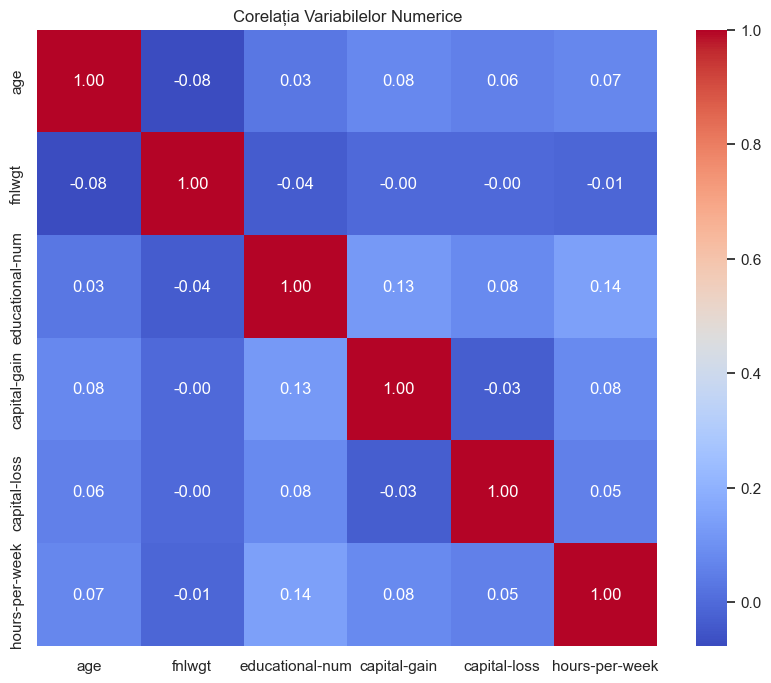

In [5]:
plt.figure(figsize=(10, 8))

corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Corelația Variabilelor Numerice')
plt.show()

In [7]:
df_reg = df.copy()


for col in ['workclass', 'occupation', 'native-country']:
    if col in df_reg.columns:
        df_reg[col] = df_reg[col].fillna(df_reg[col].mode()[0])


if 'income' in df_reg.columns:
    df_reg = df_reg.drop('income', axis=1)

print(f"Valori lipsă rămase: {df_reg.isnull().sum().sum()}")

Valori lipsă rămase: 0


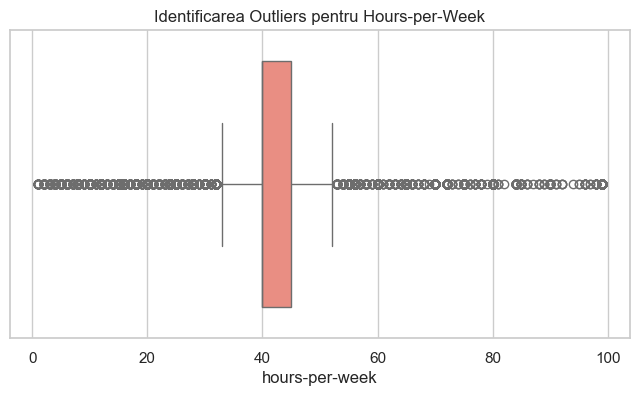

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.boxplot(x=df_reg['hours-per-week'], color='salmon')
plt.title('Identificarea Outliers pentru Hours-per-Week')
plt.show()


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_reg = df.drop(['hours-per-week', 'income'], axis=1)
y_reg = df['hours-per-week']

X_reg = pd.get_dummies(X_reg, drop_first=True)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
import numpy as np


modele_regresie = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42, n_jobs=-1),
    "Support Vector Regressor": SVR(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "XGBoost Regressor": XGBRegressor(random_state=42),
    "CatBoost Regressor": CatBoostRegressor(verbose=0, random_state=42),
    "EBM Regressor": ExplainableBoostingRegressor(random_state=42)

}

rezultate_reg_lista = []

for nume, model in modele_regresie.items():
    print(f"Antrenare {nume}...")
    model.fit(X_train_reg_scaled, y_train_reg)
    pred = model.predict(X_test_reg_scaled)

    mse = mean_squared_error(y_test_reg, pred)
    mae = mean_absolute_error(y_test_reg, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_reg, pred)

    rezultate_reg_lista.append({
        "Model": nume,
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    })

df_rezultate_reg = pd.DataFrame(rezultate_reg_lista).sort_values(by="MAE")
display(df_rezultate_reg)

Antrenare Linear Regression...
Antrenare Decision Tree Regressor...
Antrenare Random Forest Regressor...
Antrenare Support Vector Regressor...
Antrenare K-Neighbors Regressor...
Antrenare XGBoost Regressor...
Antrenare CatBoost Regressor...
Antrenare EBM Regressor...


,Model,MSE,MAE,RMSE,R2
3,Support Vector Regressor,124.5837,6.9583,11.1617,0.1756
6,CatBoost Regressor,109.7790,7.1653,10.4775,0.2736
7,EBM Regressor,110.9783,7.2232,10.5346,0.2657
5,XGBoost Regressor,112.1513,7.2744,10.5901,0.2579
2,Random Forest Regressor,120.0696,7.6105,10.9576,0.2055
0,Linear Regression,123.6422,7.7415,11.1195,0.1819
4,K-Neighbors Regressor,135.2684,8.1524,11.6305,0.1049
1,Decision Tree Regressor,231.6441,10.1959,15.2199,-0.5328


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evalueaza_regresor(nume_model, model, X_test, y_test):
    """
    Funcție pentru calcularea metricilor de regresie și returnarea lor sub formă de dicționar.
    """

    predictii = model.predict(X_test)


    mse = mean_squared_error(y_test, predictii)
    mae = mean_absolute_error(y_test, predictii)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictii)


    return {
        "Model": nume_model,
        "MSE": round(mse, 4),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4)
    }

In [16]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


X_train_gpr_sample = X_train_reg_scaled[:2000]
y_train_gpr_sample = y_train_reg[:2000]

print("Antrenare Gaussian Process Regressor (pe eșantion)...")
gpr = GaussianProcessRegressor(kernel=C(1.0) * RBF(1.0), alpha=0.1, random_state=42)
gpr.fit(X_train_gpr_sample, y_train_gpr_sample)


rezultate_reg_lista.append(evalueaza_regresor("Gaussian Process Regressor", gpr, X_test_reg_scaled, y_test_reg))


df_rezultate_reg = pd.DataFrame(rezultate_reg_lista).sort_values(by="MAE")
display(df_rezultate_reg)

Antrenare Gaussian Process Regressor (pe eșantion)...


,Model,MSE,MAE,RMSE,R2
3,Support Vector Regressor,124.5837,6.9583,11.1617,0.1756
6,CatBoost Regressor,109.7790,7.1653,10.4775,0.2736
7,EBM Regressor,110.9783,7.2232,10.5346,0.2657
5,XGBoost Regressor,112.1513,7.2744,10.5901,0.2579
2,Random Forest Regressor,120.0696,7.6105,10.9576,0.2055
0,Linear Regression,123.6422,7.7415,11.1195,0.1819
4,K-Neighbors Regressor,135.2684,8.1524,11.6305,0.1049
1,Decision Tree Regressor,231.6441,10.1959,15.2199,-0.5328
8,Gaussian Process Regressor,1778.6168,40.3295,42.1737,-10.7690


In [17]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV


param_grid_svr = {
    'C': [0.1, 1, 10],
    'epsilon': [0.01, 0.1, 0.2],
    'kernel': ['rbf']
}
grid_svr = GridSearchCV(SVR(), param_grid_svr, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_svr.fit(X_train_reg_scaled[:2000], y_train_reg.iloc[:2000])


param_dist_cat = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'iterations': [100, 200]
}
grid_cat = RandomizedSearchCV(CatBoostRegressor(verbose=0), param_dist_cat, n_iter=5, cv=3, scoring='neg_mean_absolute_error')
grid_cat.fit(X_train_reg_scaled, y_train_reg)


param_dist_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
grid_xgb = RandomizedSearchCV(XGBRegressor(), param_dist_xgb, n_iter=5, cv=3, scoring='neg_mean_absolute_error')
grid_xgb.fit(X_train_reg_scaled, y_train_reg)


param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
grid_rf.fit(X_train_reg_scaled, y_train_reg)


ebm_tuned = ExplainableBoostingRegressor(interactions=10, learning_rate=0.01, random_state=42)
ebm_tuned.fit(X_train_reg_scaled, y_train_reg)

,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,10
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.01
,greedy_ratio,10.0


In [18]:
rezultate_final = []
best_models = {
    "SVR_Tuned": grid_svr.best_estimator_,
    "CatBoost_Tuned": grid_cat.best_estimator_,
    "XGBoost_Tuned": grid_xgb.best_estimator_,
    "Random Forest_Tuned": grid_rf.best_estimator_,
    "EBM_Tuned": ebm_tuned
}

for nume, model in best_models.items():
    rezultate_final.append(evalueaza_regresor(nume, model, X_test_reg_scaled, y_test_reg))

df_final = pd.DataFrame(rezultate_final).sort_values(by="MAE")
display(df_final)

,Model,MSE,MAE,RMSE,R2
1,CatBoost_Tuned,109.8138,7.1615,10.4792,0.2734
2,XGBoost_Tuned,110.1775,7.1862,10.4965,0.2710
3,Random Forest_Tuned,111.9823,7.1880,10.5822,0.2590
4,EBM_Tuned,112.1818,7.2662,10.5916,0.2577
0,SVR_Tuned,139.2243,7.2683,11.7993,0.0788


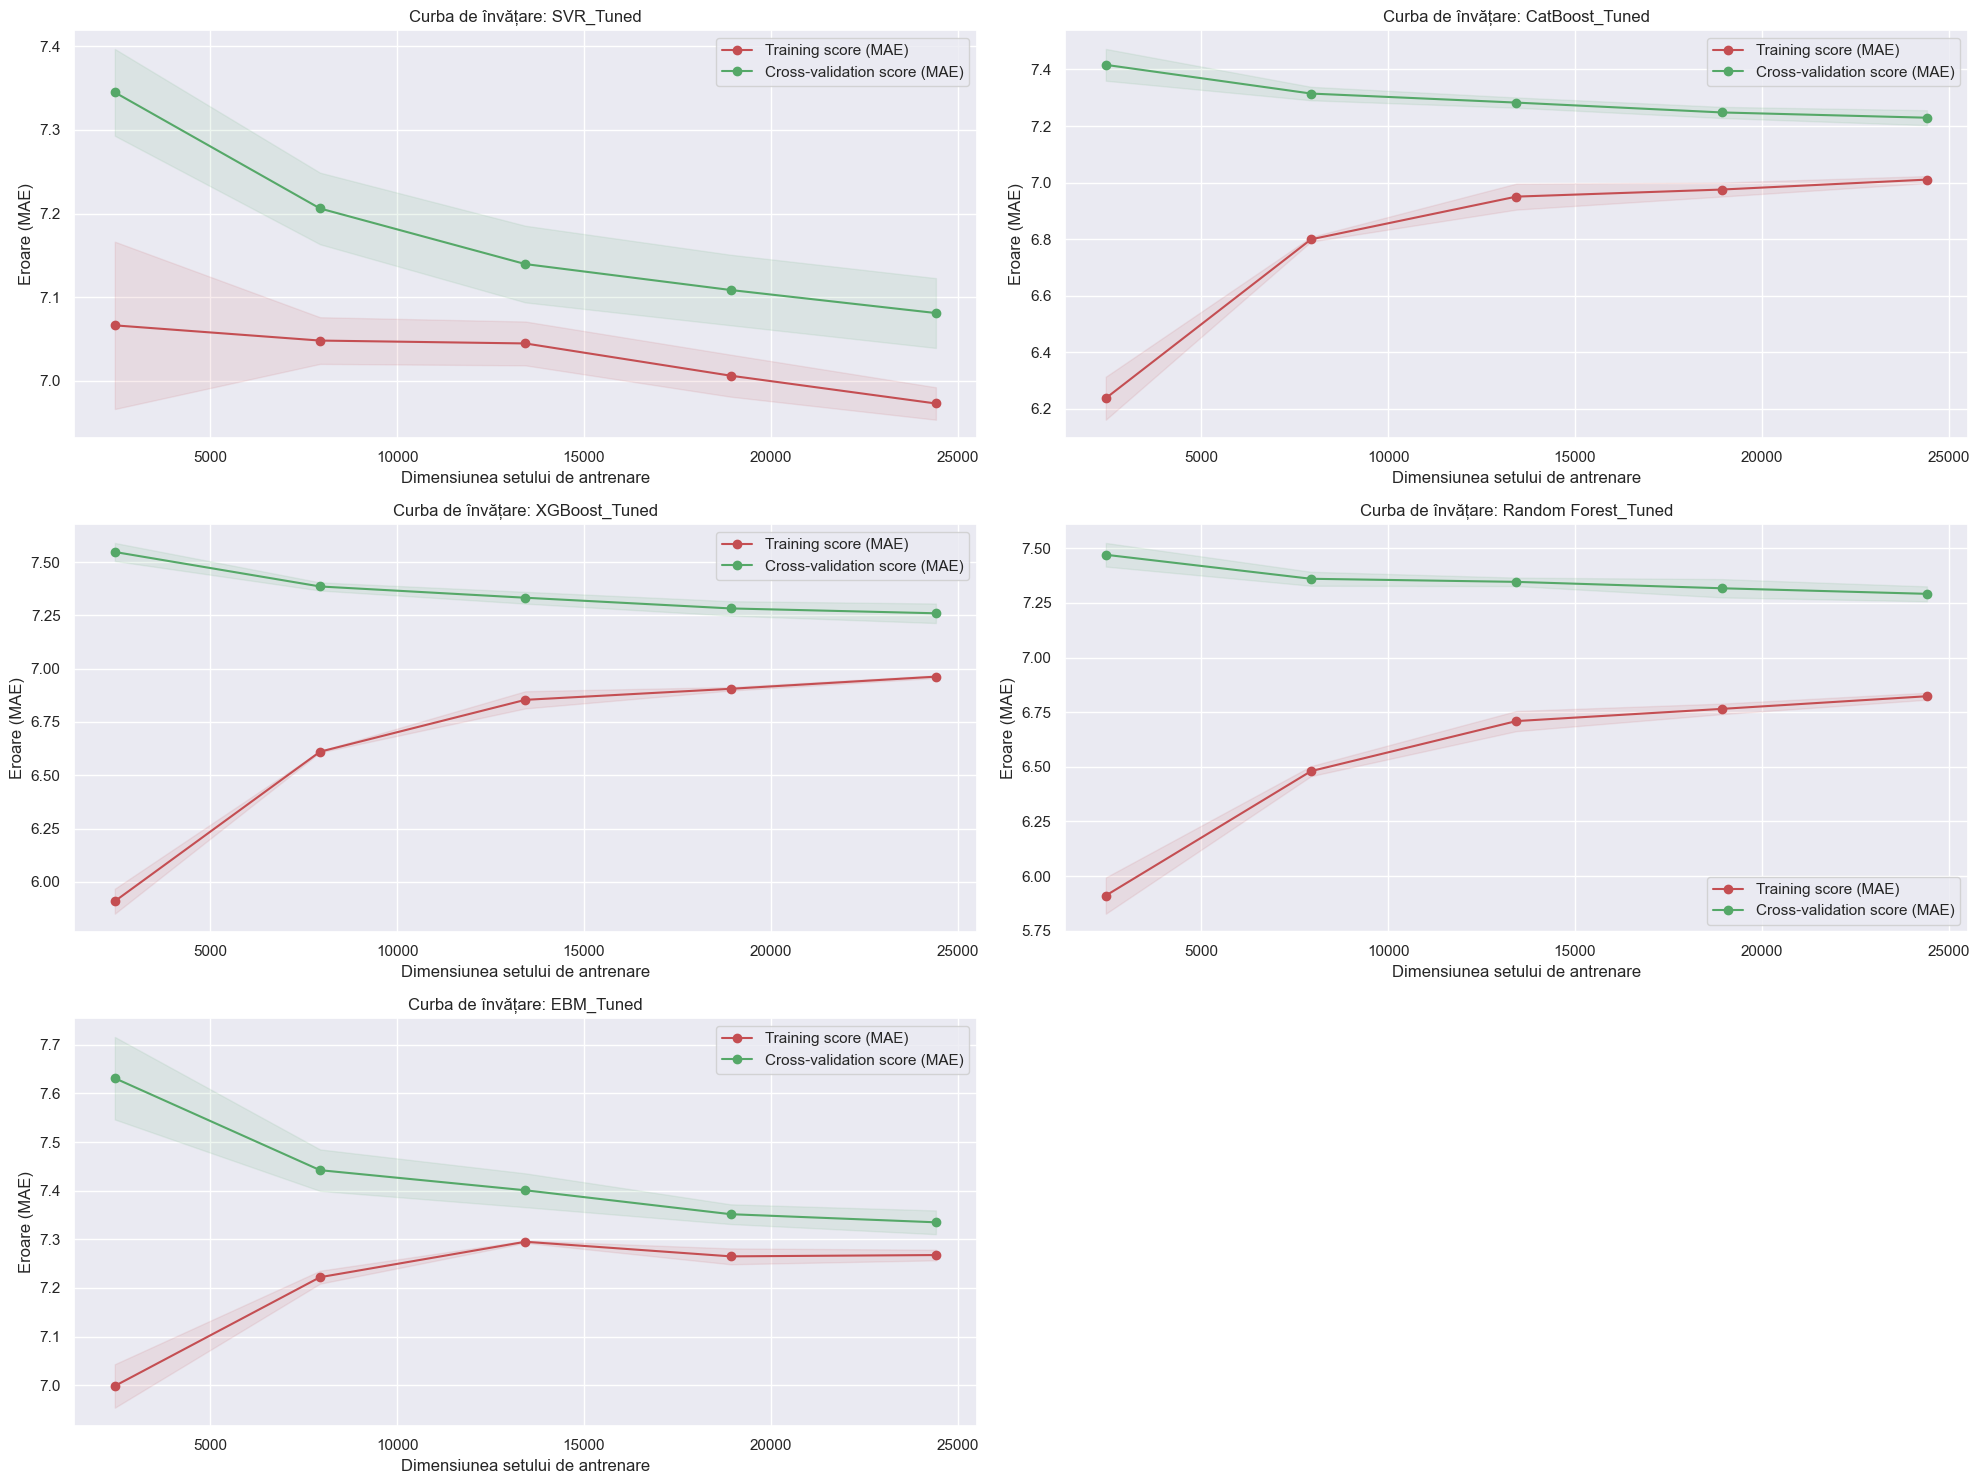

In [34]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curves(models_dict, X, y):
    plt.figure(figsize=(20, 15))

    for i, (name, model) in enumerate(models_dict.items()):
        plt.subplot(3, 2, i+1)

        train_sizes, train_scores, test_scores = learning_curve(
            model, X, y, cv=3, n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5),
            scoring='neg_mean_absolute_error'
        )

        train_mean = -np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = -np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score (MAE)")
        plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score (MAE)")

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

        plt.title(f"Curba de învățare: {name}")
        plt.xlabel("Dimensiunea setului de antrenare")
        plt.ylabel("Eroare (MAE)")
        plt.legend(loc="best")
        plt.grid(True)

    plt.tight_layout()

    plt.savefig('learning_curves_regresie.png', bbox_inches='tight', dpi=300)

    plt.show()


plot_learning_curves(best_models, X_train_reg_scaled, y_train_reg)

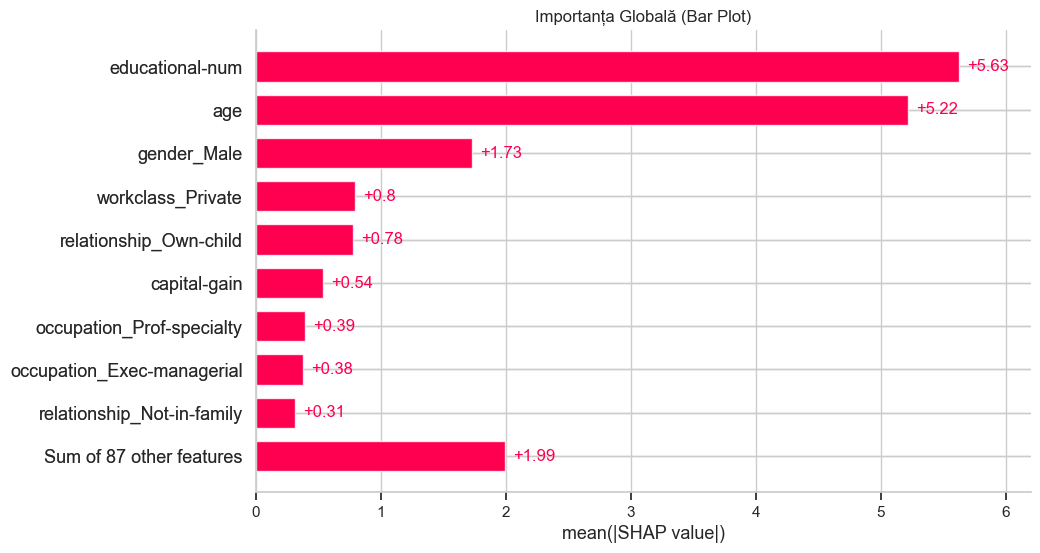

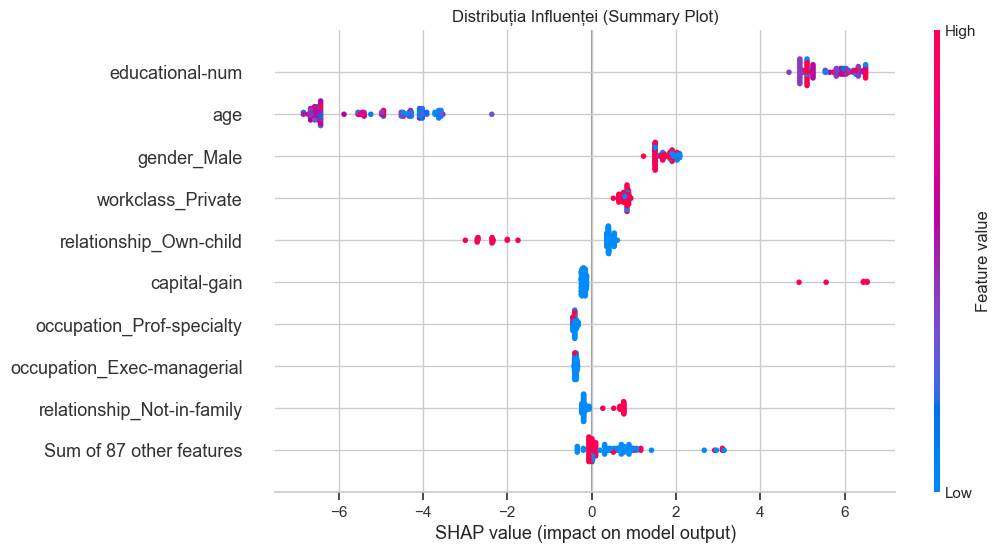

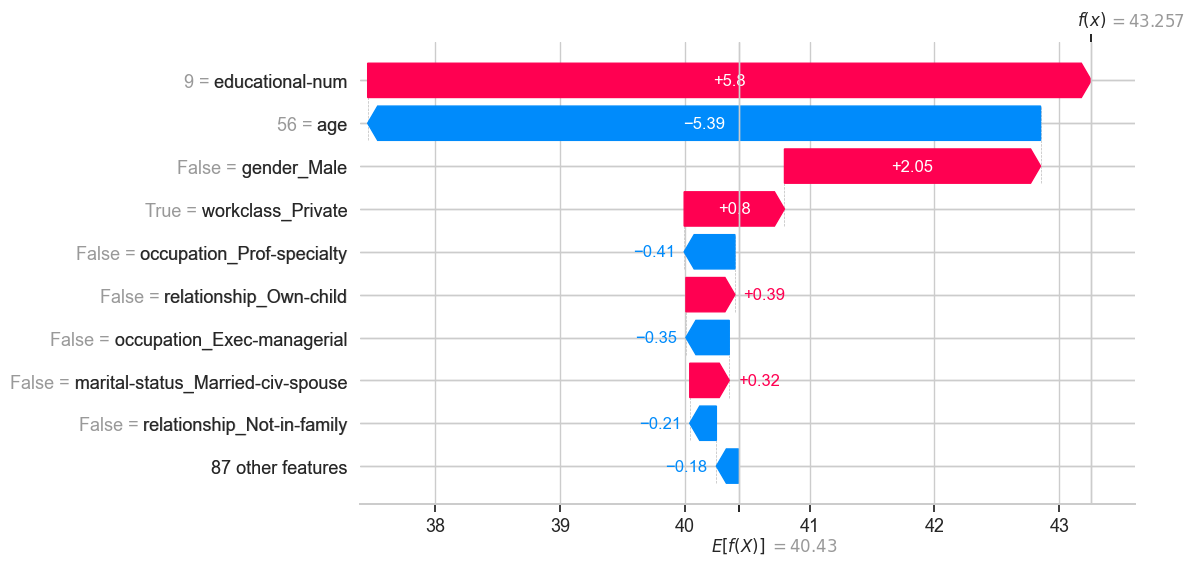

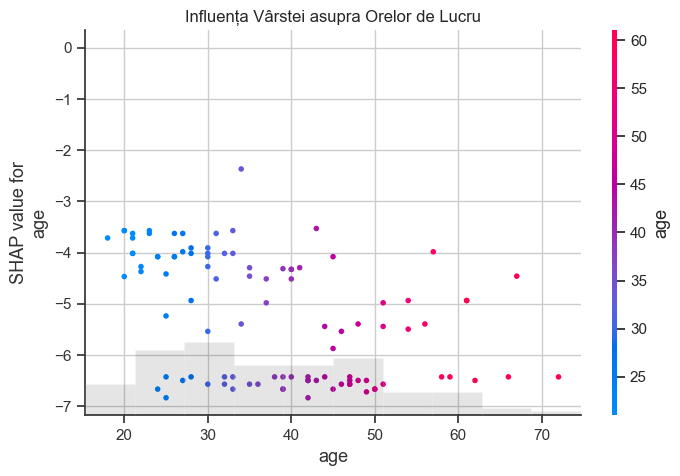

In [22]:
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(grid_cat.best_estimator_)
X_sample = X_test_reg.iloc[:100]
shap_values = explainer(X_sample)


shap.plots.bar(shap_values, show=False)
plt.title("Importanța Globală (Bar Plot)")
plt.gcf().set_size_inches(10, 6)
plt.show()

shap.plots.beeswarm(shap_values, show=False)
plt.title("Distribuția Influenței (Summary Plot)")
plt.gcf().set_size_inches(10, 6)
plt.show()

shap.plots.waterfall(shap_values[0], show=False)
plt.gcf().set_size_inches(10, 6)
plt.show()


shap.plots.scatter(shap_values[:, "age"], color=shap_values[:, "age"], show=False)
plt.title("Influența Vârstei asupra Orelor de Lucru")
plt.gcf().set_size_inches(8, 5)
plt.show()

In [24]:
import joblib

joblib.dump(grid_cat.best_estimator_, 'catboost_reg_model.joblib')
joblib.dump(grid_xgb.best_estimator_, 'xgboost_reg_model.joblib')
joblib.dump(grid_rf.best_estimator_, 'random_forest_reg_model.joblib')
joblib.dump(ebm_tuned, 'ebm_reg_model.joblib')
joblib.dump(grid_svr.best_estimator_, 'svr_reg_model.joblib')

['svr_reg_model.joblib']

In [26]:

shap.plots.beeswarm(shap_values, show=False)
plt.savefig('shap_summary_regresie.png', bbox_inches='tight', dpi=300)
plt.close()

In [28]:
import joblib
import os


joblib.dump(scaler_reg, 'scaler_reg.joblib')


print(f"Scaler-ul a fost salvat în: {os.getcwd()}\\scaler_reg.joblib")

Scaler-ul a fost salvat în: D:\FACULTATE\SEM II\SI\proiect-ml-Alexia4Pop\scaler_reg.joblib


In [29]:

import joblib
lista_coloane = list(X_train_reg.columns)
joblib.dump(lista_coloane, 'model_columns.joblib')
print("Lista de coloane a fost salvată!")

Lista de coloane a fost salvată!
